# Dimensiereductie

Auteurs: Brian van der Bijl (brian.vanderbijl@hu.nl), Tijmen Muller

- Studentnummer: 1833628
- Naam: Mathijs de Jong
- Datum: 06/03/2026

## Deel I: Principal Component Analysis (PCA)

Het _Principal Component Analysis_ (PCA) algoritme kan gebruikt worden om het aantal dimensies van een dataset te reduceren tot de belangrijkste componenten. Als de originele dataset $n$ dimensies heeft, dan kunnen we met onderstaande stappen dit terugbrengen tot een (zelfgekozen) aantal van $n^\prime$ dimensies.

1. Centreer de data.
2. Bereken de covariantie van alle features onderling. 
3. Bereken de Eigenvectors en Eigenvalues van de covariantiematrix.
4. Kies de $n^\prime$ Eigenvectors om de dimensiereductie mee uit te voeren.
5. Vermenigvuldig de $n^\prime$ Eigenvectors met de originele data om de reductie toe te passen.

### Context

Gegeven is een databestand met embeddings van 200 tekstfragmenten. Elke embedding bestaat in 15 dimensies, en is gelabeled met een categorie. We gaan dimensionaliteitsreductie toepassen om de data te kunnen plotten.

De categorie geeft aan in welk genre de tekstfragmenten thuishoren. Daarnaast is onderscheid gemaakt tussen het perspectief waarin het fragment geschreven is: ik (1st person) of hij/haar/hen (3rd person):
- Fantasy (1st person)
- Fantasy (3rd person)
- Science Fiction (1st person)
- Science Fiction (3rd person)
- Romance (1st person)
- Romance (3rd person)
- Crime (1st person)
- Crime (3rd person)

In [95]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Show floats on 3 digits, suppress scientific notation
np.set_printoptions(precision=3, suppress=True)

In [96]:
with open('data.pkl', 'rb') as file:
    data = pickle.load(file)

data.sample(5)

e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,e_9,e_10,e_11,e_12,e_13,e_14,e_15,label
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
1.225105,1.216584,1.423586,1.248953,0.965199,3.774443,0.491922,2.882402,1.151147,0.659875,0.285644,1.344977,1.0466,1.127903,0.689821,"""Fantasy (1st person)"""
0.915408,1.082771,0.561254,1.24425,0.980555,4.466845,0.935481,2.421786,1.178788,1.318846,1.113331,0.553227,0.304275,0.811613,1.129059,"""Crime (1st person)"""
0.599003,0.593364,0.843638,0.874738,0.673248,3.695112,1.574722,2.193168,1.077488,0.874312,1.75127,0.910902,1.085758,1.253294,1.015901,"""Science Fiction (3rd person)"""
1.097187,0.149071,0.960767,0.762989,1.354291,1.640393,0.330425,2.754226,1.071141,0.342698,0.995732,1.081273,0.622436,0.714259,1.316333,"""Science Fiction (1st person)"""
0.909652,1.01964,1.378795,0.71414,0.798644,3.240824,1.662984,2.572864,1.077555,0.448539,1.654374,1.060943,1.736659,0.773429,1.0813,"""Science Fiction (3rd person)"""


### Voorbereidende opdracht

Gegeven een dataset met $m$ datapunten met elk $n$ features en een gewenste reductie tot $n^\prime$ dimensies. Bepaal voor elk van de vijf stappen van het algoritme wat de dimensies (oftewel `shape`) is van de volgende tussenresultaten:

0. De matrix met de originele dataset.
1. De matrix met de gemiddelden per feature om de data mee te centreren.
2. De covariantiematrix.
3. De matrix met de Eigenvectors en de matrix met de Eigenvalues.
4. De matrix met de _geselecteerde_ Eigenvectors.
5. De matrix met de _gereduceerde_ data.

0. M datapunten (rijen) en n features (kolommen) --> de shape is (m, n).
1. Elke feature (kolom) heeft 1 gemiddelde, dus 1 rij. De shape is dus (1, n).
2. De covariantiematrix beschrijft de covariantie tussen alle features onderling. De shape is dus (n, n).
3. De eigenvectors worden berekend met de covariantiematrix. Dit wordt een matrix waarin elke kolom een eigenvector is, met 1 waarde voor elke feature. De shape is dus (n, n).
Voor elke eigenvector is er een eigenvalue, dus n eigenvalues. Dit komt in een vector met shape (n, 1)
4. We hadden de matrix met eigenvectors van shape (n, n). We gooien de kolommen (eigenvectors) weg die niet belangrijk genoeg zijn, en houden n' kolommen over. De shape is dus (n, n').
5. We vermenigvuldigen de originele dataset (m, n) met de geselecteerde eigenvectors (n, n'), dus de shape van het resultaat wordt: (m, n').

### Opdracht 1. Implementatie

Schrijf een eigen implementatie van het PCA-algoritme `compute_pca(X, n_components)` volgens eerdergenoemde stappen van het algoritme. Maak slim gebruik van fucties van `numpy` waar mogelijk, maar zorg wel dat je begrijpt wat je in elke stap doet. De laatste stap is al gegeven in de functiedefinitie hieronder.

Hint: Laat bij stap 3. zien (bijvoorbeeld met een `print()` statement) dat de meest informatieve Eigenvalue al meer dan 50% van de informatie bevat van onze dataset.

#### Input
- `X: numpy.array` - numpy matrix met dimensies $(m, n)$; elke rij is een datapunt in $n$ dimensies
- `n_components: int` - het gewenste aantal dimensies $n^\prime$

#### Output
`X_reduced: numpy.array` - een $(m, n^\prime)$ numpy matrix met de gereduceerde data.

In [97]:
def compute_pca(X, n_components):
    """
    Parameters
    ----------
    X : numpy.ndarray
        Input data matrix of shape (m, n), where m is the number of samples and n is the number of features.
    n_components : int
        The number of principal components (dimensions) to keep.

    Returns
    -------
    X_reduced : numpy.ndarray
        The data projected onto the top n_components principal components.
    """
    arr = np.array(X)

    # 1. Data centreren
    # Centreren: gemiddelde per feature (kolom) berekenen en dat van de kolom af trekken
    gem_per_feature = np.mean(arr, axis=0)
    arr_gecentreerd = arr - gem_per_feature

    # 2. Covariantie-matrix maken
    covariance_matrix = np.cov(arr_gecentreerd, rowvar=False, ddof=1)

    # 3. Eigenvalues en eigenvector van de covariantie-matrix berekenen
    eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
    ##print(f"DEBUGGING: Eigenvalues van eigenvectors: {eigenvalues.real}")
    ##print(f"DEBUGGING: Eigenvectors (kolommen):\n{eigenvectors.real}")

    # 4. De n' beste eigenvectors selecteren om reductie mee te doen
    # De eigenvalues van de eigenvectors beslissen de ranking
    # Eigenvectors sorteren op volgorde van hoogste eigenvalue naar laagste eigenvalue
    indexen_gesorteerd = np.argsort(eigenvalues)    # geeft de indexen die de lijst zouden sorteren
    indexen_gesorteerd = indexen_gesorteerd[::-1]   # lijst omdraaien zodat die van hoog naar laag loopt

    eigenvectors_gesorteerd = eigenvectors[:, indexen_gesorteerd]   # sorteer de kolommen (eigenvectors)

    # De top n' eigenvectors selecteren
    n_eigenvectors = eigenvectors_gesorteerd[:, :n_components]

    # 5. De data reduceren
    return arr_gecentreerd @ n_eigenvectors

#### Test-scenario
Onderstaande code zou de volgende output moeten opleveren (het minteken kan wisselen):

```python
[[ 0.43437323 -0.49820384]
 [ 0.42077249  0.50351448]
 [-0.85514571 -0.00531064]]
 ```

In [98]:
np.random.seed(1)
X = np.random.rand(3, 10)
X_reduced = compute_pca(X, n_components=2)
print(f"Gereduceerde data (output):\n{X_reduced.real}")

Gereduceerde data (output):
[[ 0.434 -0.498]
 [ 0.421  0.504]
 [-0.855 -0.005]]


Hierboven (als de DEBUGGING regels in mijn code uit de comments worden gehaald) zien we de eigenvalues van het test-scenario. Het valt op dat de 1e kolom (eigenvector) ongeveer 2/3e van de informatie bevat. De 2e kolom ongeveer 1/3e en de rest niks.

In dit geval is het dus ideaal om naar 2 dimensies te reduceren, zoals in de voorbeeldcode gedaan wordt.

### Opdracht 2. Visualisatie met dimensiereductie

Maak op basis van de aangeleverde `data` een numpy array van de datapunten, en gebruik je PCA-implementatie om een 2D- en 3D-weergave van de data te maken. Maak van elke weergave een plot, waarbij iedere categorie een eigen kleur krijgt.

C:\Users\mathi\AppData\Local\Temp\ipykernel_30368\517529631.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))


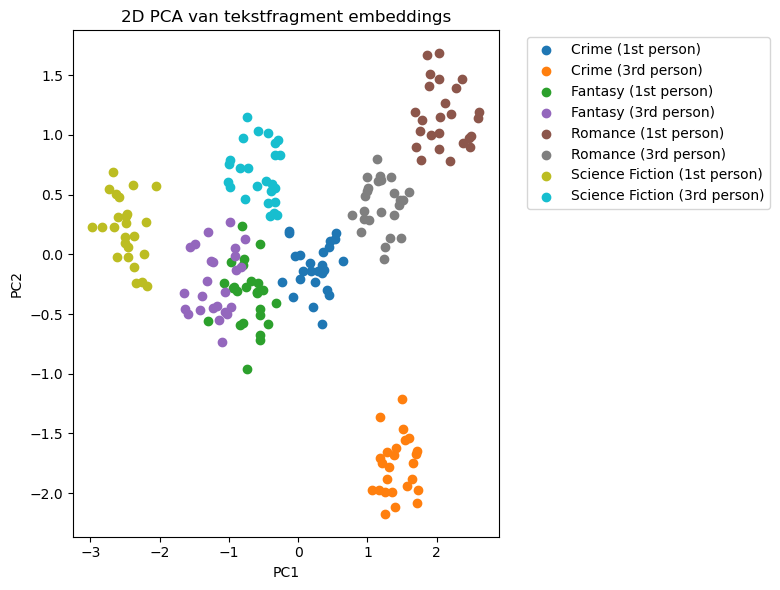

In [99]:
# 2D weergave
# Data reduceren
##print(type(data))   # data is een polars dataframe
arr = np.array(data.drop("label"))
arr_reduced_2d = compute_pca(arr, n_components=2)
##print(f"Gereduceerde data (output):\n{arr_reduced_2d.real}")

# Labels
labels = np.array(data["label"])

# Unieke labels en kleuren
unique_labels = np.unique(labels)
colors = plt.cm.get_cmap("tab10", len(unique_labels))

# 4 Plotten
plt.figure(figsize=(8,6))
for i, lbl in enumerate(unique_labels):
    mask = labels == lbl
    plt.scatter(arr_reduced_2d[mask, 0], arr_reduced_2d[mask, 1], 
                label=lbl, color=colors(i))

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA van tekstfragment embeddings")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

C:\Users\mathi\AppData\Local\Temp\ipykernel_30368\3794967975.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))


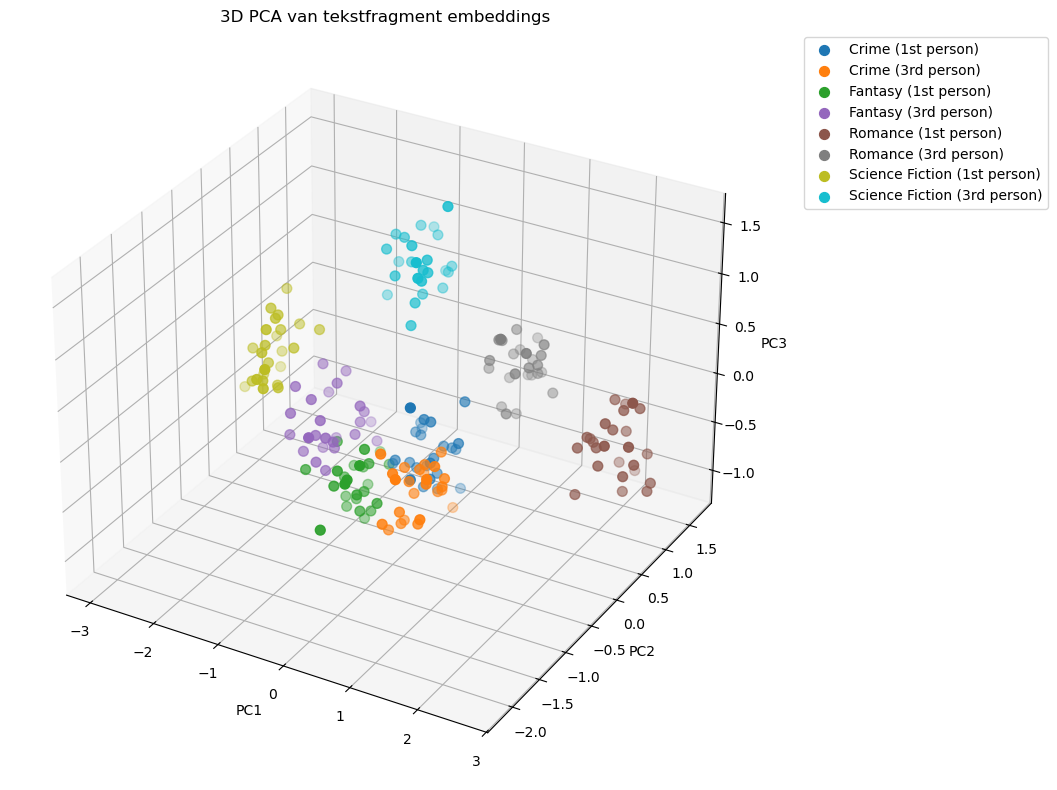

In [100]:
# 3D weergave
arr_reduced_3d = compute_pca(arr, n_components=3)
##print(f"Gereduceerde data (output):\n{arr_reduced_3d.real}")

# Labels
labels = np.array(data["label"])

# Unieke labels en kleuren
unique_labels = np.unique(labels)
colors = plt.cm.get_cmap("tab10", len(unique_labels))

# 3D plotten
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for i, lbl in enumerate(unique_labels):
    mask = labels == lbl
    ax.scatter(arr_reduced_3d[mask, 0], 
               arr_reduced_3d[mask, 1], 
               arr_reduced_3d[mask, 2], 
               label=lbl, color=colors(i), s=50)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA van tekstfragment embeddings")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Opdracht 3. Analyse

Analyseer de resultaten:
1. Welke categorieën zijn op basis van de PCA-reductie te onderscheiden, en welke niet? 
2. Geef aan hoeveel procent van de informatie bewaard is gebleven in 2D en 3D respectievelijk.
3. Hoeveel dimensies zijn nodig om 90% van de informatie te bewaren?
4. En voor 95%?

Het valt op dat genre Crime(3rd person) in de 3D-weergave ver weg van de andere clusters ligt, maar in 3D-weergave ligt deze verwoven met meerdere clusters. In principe zijn hogere PC's betrouwbaarder omdat meer informatie bewaard blijft. Daarom ga ik voor de analyse mijn antwoorden baseren op die van de 3D-weergave.

1. De categorieën die op basis van de PCA-reductie te onderscheiden zijn, zijn als volgt:
- Science Fiction (1st person)
- Science Fiction (3rd person)
- Romance (3rd person)
- Romance (1st person)
- Fantasy (3rd person) is al wat moeilijker te onderscheiden
- De overige genres (Crime 1st en 3rd person, Fantasy 1st person) liggen in elkaar, wat ze niet te onderscheiden maakt.

Zoals eerder genoemd is Crime (3rd person) wel goed te onderscheiden in de 2D-plot, maar deze is in principe minder betrouwbaar omdat er meer dimensies gereduceerd zijn.

2. Ik bereken de percentages met behulp van de explained variance van PCA:

In [101]:
# Covariantie-matrix
cov_matrix = np.cov(arr, rowvar=False, ddof=1)

# Eigenvalues berekenen
eigvals, eigvecs = np.linalg.eig(cov_matrix)
print(eigvals)

# Percentage variantie per principal component
explained_variance_ratio = eigvals / np.sum(eigvals)

# Info bewaard in 2D en 3D
info_2D = np.sum(explained_variance_ratio[:2]) * 100
info_3D = np.sum(explained_variance_ratio[:3]) * 100

print(f"Percentage informatie bewaard in 2D: {info_2D:.1f}%")
print(f"Percentage informatie bewaard in 3D: {info_3D:.1f}%")

[2.113 0.733 0.354 0.194 0.158 0.114 0.084 0.069 0.06  0.054 0.052 0.045
 0.042 0.036 0.036]
Percentage informatie bewaard in 2D: 68.7%
Percentage informatie bewaard in 3D: 77.2%


Voor 2D houdt dit in dat ik kijk naar de totale variantie (de som van eigenvalues), en hoe deze zich verhoudt met de 2 meest informatieve dimensies. Dit komt uit op 68.7% informatie bewaard.

Voor 3D komt dit uit op 77.2% van de informatie bewaard.

3. Ik bereken voor elke hoeveelheid dimensies het percentage overgebleven informatie:

In [102]:
sum = np.sum(eigvals)
for dimensie in range(len(eigvals)):
    print(f"Dimensies: {dimensie+1} | Informatie behouden: {np.sum(eigvals[:dimensie+1])/sum*100:.2f}%")

Dimensies: 1 | Informatie behouden: 50.98%
Dimensies: 2 | Informatie behouden: 68.67%
Dimensies: 3 | Informatie behouden: 77.22%
Dimensies: 4 | Informatie behouden: 81.90%
Dimensies: 5 | Informatie behouden: 85.72%
Dimensies: 6 | Informatie behouden: 88.46%
Dimensies: 7 | Informatie behouden: 90.49%
Dimensies: 8 | Informatie behouden: 92.15%
Dimensies: 9 | Informatie behouden: 93.61%
Dimensies: 10 | Informatie behouden: 94.91%
Dimensies: 11 | Informatie behouden: 96.17%
Dimensies: 12 | Informatie behouden: 97.25%
Dimensies: 13 | Informatie behouden: 98.26%
Dimensies: 14 | Informatie behouden: 99.12%
Dimensies: 15 | Informatie behouden: 100.00%


Om 90% van de informatie te behouden zijn minimaal 7 dimensies nodig (90.49%).

4. Om 95% van de informatie te behouden zijn minimaal 11 dimensies nodig (96.17%). 10 dimensies ligt dichterbij de 95%, maar voldoet technisch gezien niet aan de norm omdat die net onder de 95% zit.

## Deel II: t-Distributed Stochastic Neighbour Embedding (t-SNE)

Een alternatieve methode voor dimensiereductie is _t-Distributed Stochastic Neighbour Embedding_ (t-SNE). 

### Opdracht 4. Toepassing
Gebruik SciKit-Learn om met behulp van t-SNE de data tot 2 dimensies te reduceren en plot het resultaat (wederom met kleuren voor de categorien). 

C:\Users\mathi\AppData\Local\Temp\ipykernel_30368\3438279576.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))


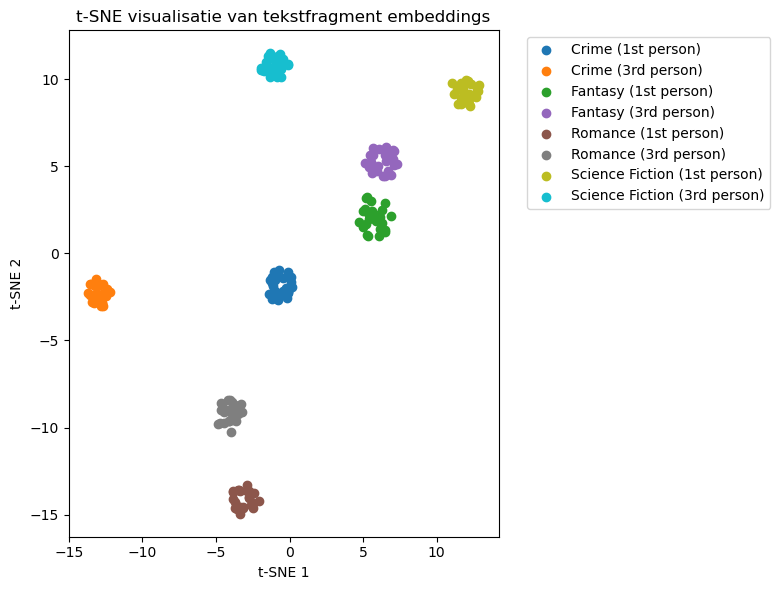

In [103]:
# t-SNE uitvoeren voor reductie naar 2 dimensies
tsne = TSNE(n_components=2)
arr_reduced_tsne_2d = tsne.fit_transform(arr)

# Unieke labels en kleuren
unique_labels = np.unique(labels)
colors = plt.cm.get_cmap("tab10", len(unique_labels))

plt.figure(figsize=(8,6))

for i, lbl in enumerate(unique_labels):
    mask = labels == lbl
    plt.scatter(arr_reduced_tsne_2d[mask, 0],
                arr_reduced_tsne_2d[mask, 1],
                label=lbl,
                color=colors(i))

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE visualisatie van tekstfragment embeddings")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Er is met deze methode zeer goed onderscheid te maken tussen de genres van de datapunten.

### Opdracht 5. Vergelijking

Vergelijk deze met de resultaten van je PCA-implementatie:

1. Hoe verhoudt de zichtbaarheid van de categorieën zich tussen beide resultaten?  
Bij PCA waren er een paar genres die niet goed te onderscheiden waren. Bij t-SNE zijn alle genres heel goed te onderscheiden.
2. Hoe verhouden de algoritmes zich in het behoud van informatie?  
PCA behoudt de globale structuur van de data beter. Je kunt het exacte percentage behouden informatie berekenen, en de afstanden in de plot hebben betekenis. t-SNE daarentegen focust op lokale relaties tussen punten (aka clusters), waardoor de afstanden in de plot niet betrouwbaar zijn en de totale informatie minder goed behouden blijft. Je kunt ook niet berekenen hoeveel % van de informatie behouden blijft bij t-SNE. Het voordeel van t-SNE is dat je wel makkelijker clusters kunt onderscheiden dan bij PCA.

Beantwoord de volgende vragen los van de data van deze opdracht:

3. Waarvoor zou je PCA en t-SNE inzetten als je te maken krijgt met een onbekende (mogelijk ongelabelde) dataset?
4. Geef een voorbeeld waar PCA de voorkeur heeft boven t-SNE.
5. Geef een voorbeeld waar t-SNE de voorkeur heeft boven PCA.

_Schrijf hier je antwoord._

### Opdracht 6. Project

Als het goed is, heb je op dit moment een eerste idee van de data waar je in het project mee gaat werken. Geef antwoord op onderstaande vragen.

1. Wat is de dimensionaliteit waar je mee te maken hebt?
2. Beschrijf hoe dimensionaliteitsreductie-algoritmen je kunnen helpen de data te verkennen.

_Schrijf hier je antwoord._